In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    "../data/raw/AAPL_historical.csv"
)

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,24.171761,27.332500,27.860001,26.837500,27.847500,212818400
1,2015-01-05,23.490803,26.562500,27.162500,26.352501,27.072500,257142000
2,2015-01-06,23.493011,26.565001,26.857500,26.157499,26.635000,263188400
3,2015-01-07,23.822435,26.937500,27.049999,26.674999,26.799999,160423600
4,2015-01-08,24.737747,27.972500,28.037500,27.174999,27.307501,237458000


In [3]:
print("Dataset Shape:", df.shape)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (2922, 7)
Rows: 2922
Columns: 7


In [4]:
print("Columns:")

for column in df.columns:
    print(column)

Columns:
Date
Adj Close
Close
High
Low
Open
Volume


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2922 non-null   str    
 1   Adj Close  2921 non-null   float64
 2   Close      2921 non-null   float64
 3   High       2922 non-null   float64
 4   Low        2922 non-null   float64
 5   Open       2922 non-null   float64
 6   Volume     2922 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 188.5 KB


In [6]:
df["Date"] = pd.to_datetime(
    df["Date"]
)

print(df["Date"].dtype)

datetime64[us]


In [7]:
df = (
    df.sort_values("Date")
      .reset_index(drop=True)
)

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,24.171761,27.332500,27.860001,26.837500,27.847500,212818400
1,2015-01-05,23.490803,26.562500,27.162500,26.352501,27.072500,257142000
2,2015-01-06,23.493011,26.565001,26.857500,26.157499,26.635000,263188400
3,2015-01-07,23.822435,26.937500,27.049999,26.674999,26.799999,160423600
4,2015-01-08,24.737747,27.972500,28.037500,27.174999,27.307501,237458000


In [8]:
missing_values = df.isnull().sum()

print(missing_values)

Date         0
Adj Close    1
Close        1
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [9]:
missing_percentage = (
    df.isnull().mean() * 100
).round(2)

print(missing_percentage)

Date         0.00
Adj Close    0.03
Close        0.03
High         0.00
Low          0.00
Open         0.00
Volume       0.00
dtype: float64


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [11]:
duplicate_dates = df["Date"].duplicated().sum()

print(
    "Duplicate dates:",
    duplicate_dates
)

Duplicate dates: 0


In [12]:
df.describe()

,Date,Adj Close,Close,High,Low,Open,Volume
count,2922,2921.000000,2921.000000,2922.000000,2922.000000,2922.000000,2.922000e+03
mean,2020-10-21 23:51:37.330595,115.374168,117.866460,119.109652,116.637079,117.820443,1.081611e+08
min,2015-01-02 00:00:00,20.548145,22.584999,22.917500,22.367500,22.500000,1.791060e+07
25%,2017-11-24 18:00:00,37.456200,40.222500,40.576876,39.785000,40.111874,6.027562e+07
50%,2020-10-20 12:00:00,113.699257,117.320000,119.169998,116.090000,117.794998,9.096595e+07
75%,2023-09-17 06:00:00,175.129532,177.820007,179.582500,176.200005,177.470001,1.343200e+08
max,2026-08-17 00:00:00,339.786926,340.079987,344.570007,337.350006,340.029999,6.488252e+08
std,NaN,82.419494,81.958088,82.825468,81.118076,81.918424,6.780845e+07


In [13]:
print(
    "Start Date:",
    df["Date"].min()
)

print(
    "End Date:",
    df["Date"].max()
)

Start Date: 2015-01-02 00:00:00
End Date: 2026-08-17 00:00:00


In [14]:
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume
2917,2026-08-11,304.910004,304.910004,309.970001,302.790009,307.750000,37476700
2918,2026-08-12,302.250000,302.250000,305.660004,300.570007,305.100006,41657800
2919,2026-08-13,305.260010,305.260010,306.000000,302.049988,304.209991,40349300
2920,2026-08-14,305.929993,305.929993,307.489990,304.299988,306.000000,28229400
2921,2026-08-17,NaN,NaN,307.660004,302.938995,306.209991,32743947


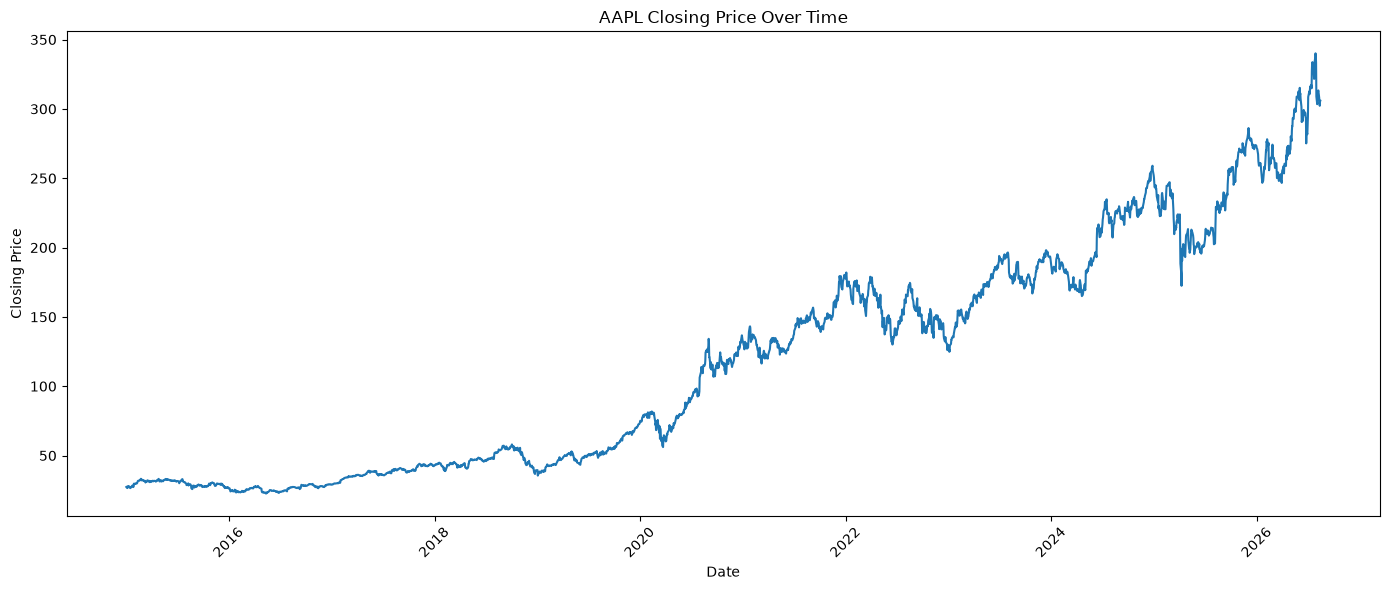

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.title(
    "AAPL Closing Price Over Time"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

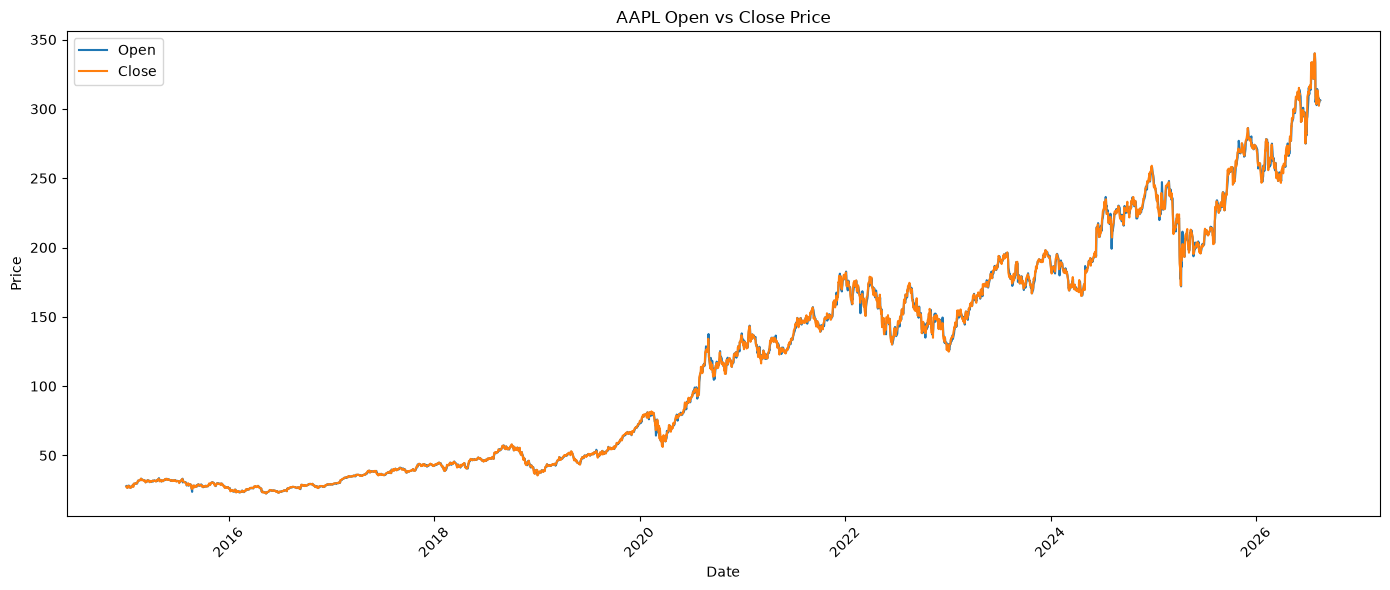

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Open"],
    label="Open"
)

plt.plot(
    df["Date"],
    df["Close"],
    label="Close"
)

plt.title(
    "AAPL Open vs Close Price"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

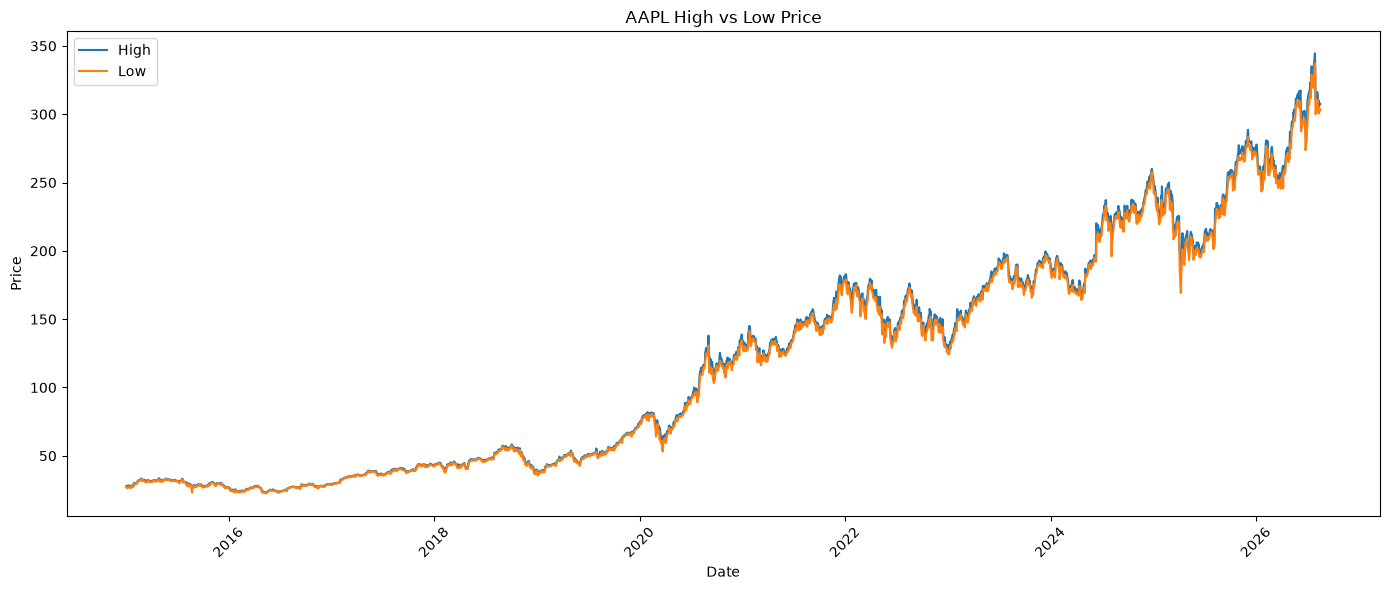

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["High"],
    label="High"
)

plt.plot(
    df["Date"],
    df["Low"],
    label="Low"
)

plt.title(
    "AAPL High vs Low Price"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

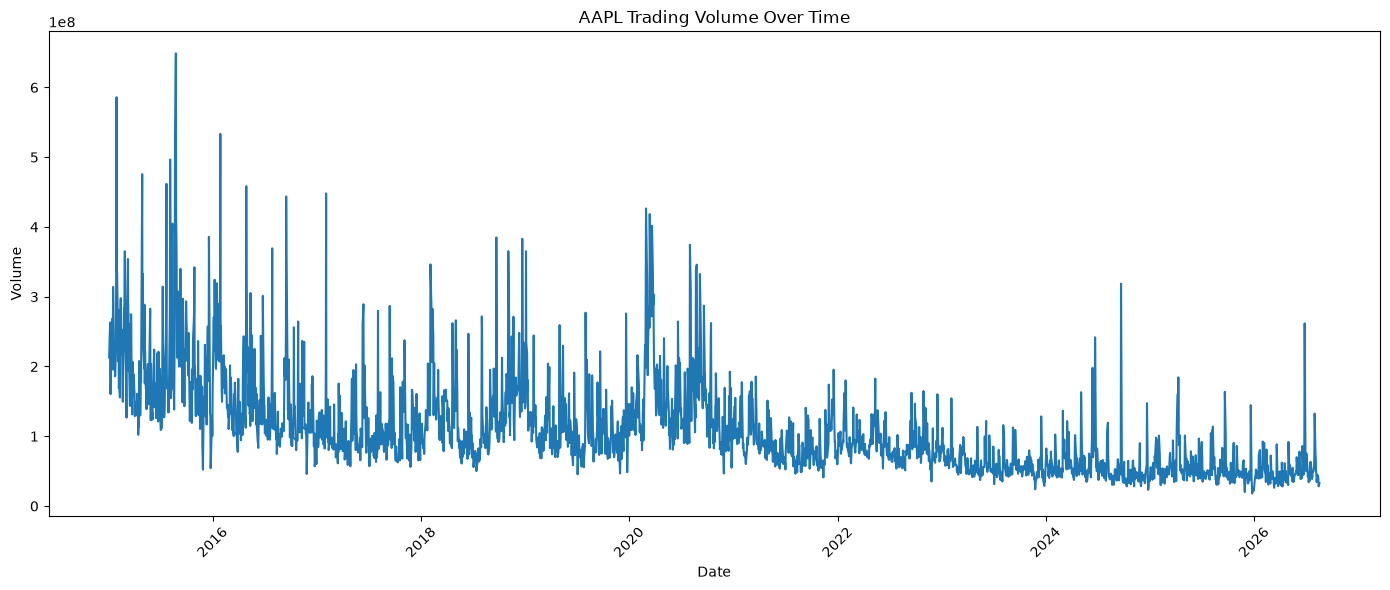

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Volume"]
)

plt.title(
    "AAPL Trading Volume Over Time"
)

plt.xlabel("Date")
plt.ylabel("Volume")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

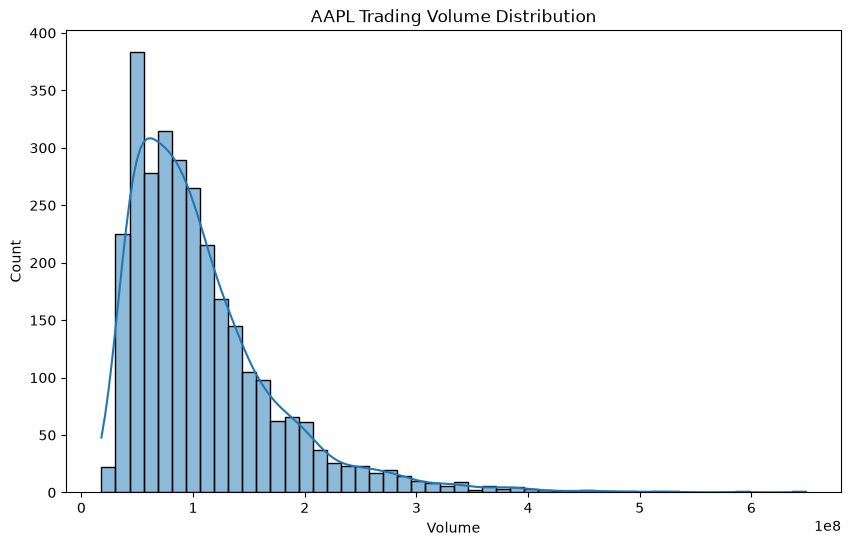

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Volume"],
    bins=50,
    kde=True
)

plt.title(
    "AAPL Trading Volume Distribution"
)

plt.xlabel("Volume")

plt.show()

In [20]:
df["Daily_Return"] = (
    df["Close"].pct_change()
)

df[
    ["Date", "Close", "Daily_Return"]
].head(10)

,Date,Close,Daily_Return
0,2015-01-02,27.332500,NaN
1,2015-01-05,26.562500,-0.028172
2,2015-01-06,26.565001,0.000094
3,2015-01-07,26.937500,0.014022
4,2015-01-08,27.972500,0.038422
5,2015-01-09,28.002501,0.001073
6,2015-01-12,27.312500,-0.024641
7,2015-01-13,27.555000,0.008879
8,2015-01-14,27.450001,-0.003811
9,2015-01-15,26.705000,-0.027140


In [21]:
df["Daily_Return"].describe()

count    2920.000000
mean        0.000992
std         0.018135
min        -0.128647
25%        -0.007419
50%         0.000942
75%         0.009889
max         0.153289
Name: Daily_Return, dtype: float64

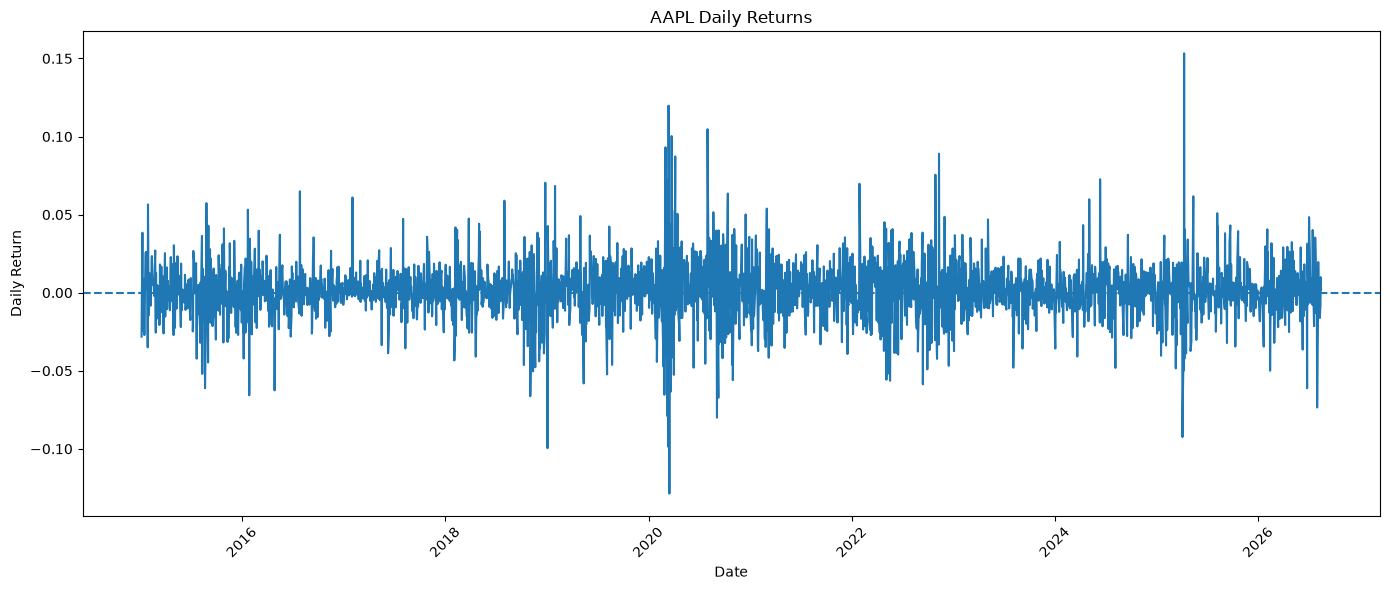

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Daily_Return"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "AAPL Daily Returns"
)

plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

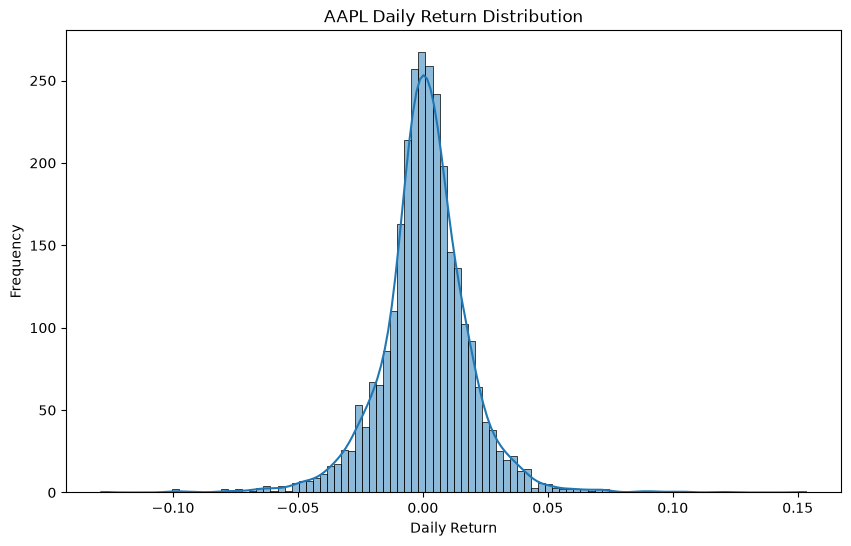

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "AAPL Daily Return Distribution"
)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [24]:
numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

correlation = (
    df[numeric_columns]
    .corr()
)

correlation

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.999845,0.999856,0.999682,0.999645,-0.584936
High,0.999845,1.000000,0.999807,0.999859,0.999819,-0.582007
Low,0.999856,0.999807,1.000000,0.999857,0.999824,-0.587826
Close,0.999682,0.999859,0.999857,1.000000,0.999960,-0.584759
Adj Close,0.999645,0.999819,0.999824,0.999960,1.000000,-0.585053
Volume,-0.584936,-0.582007,-0.587826,-0.584759,-0.585053,1.000000


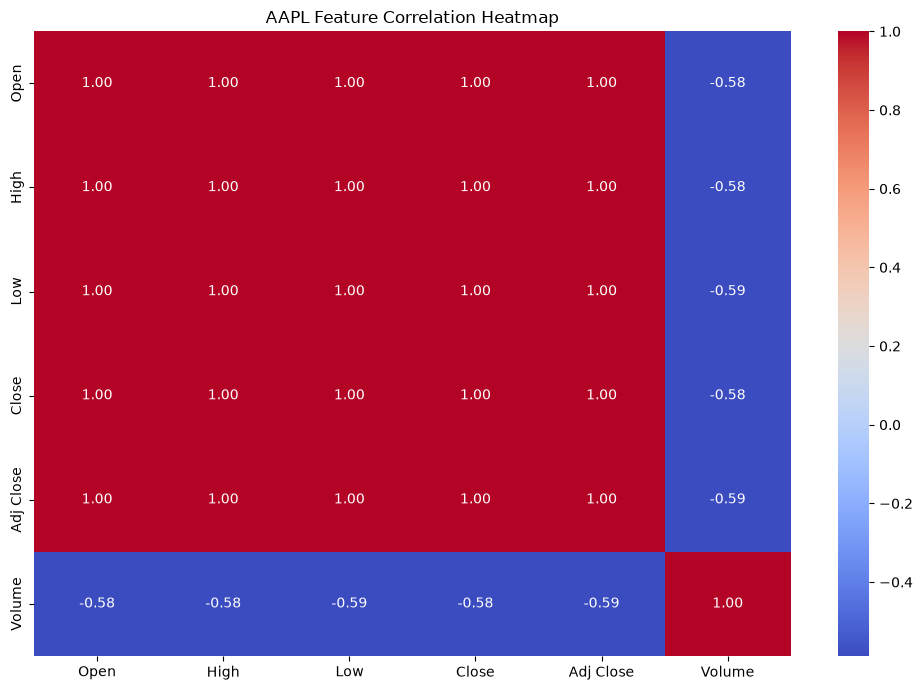

In [25]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "AAPL Feature Correlation Heatmap"
)

plt.tight_layout()

plt.show()

In [26]:
df["SMA_20"] = (
    df["Close"]
    .rolling(20)
    .mean()
)

df["SMA_50"] = (
    df["Close"]
    .rolling(50)
    .mean()
)

df["SMA_200"] = (
    df["Close"]
    .rolling(200)
    .mean()
)

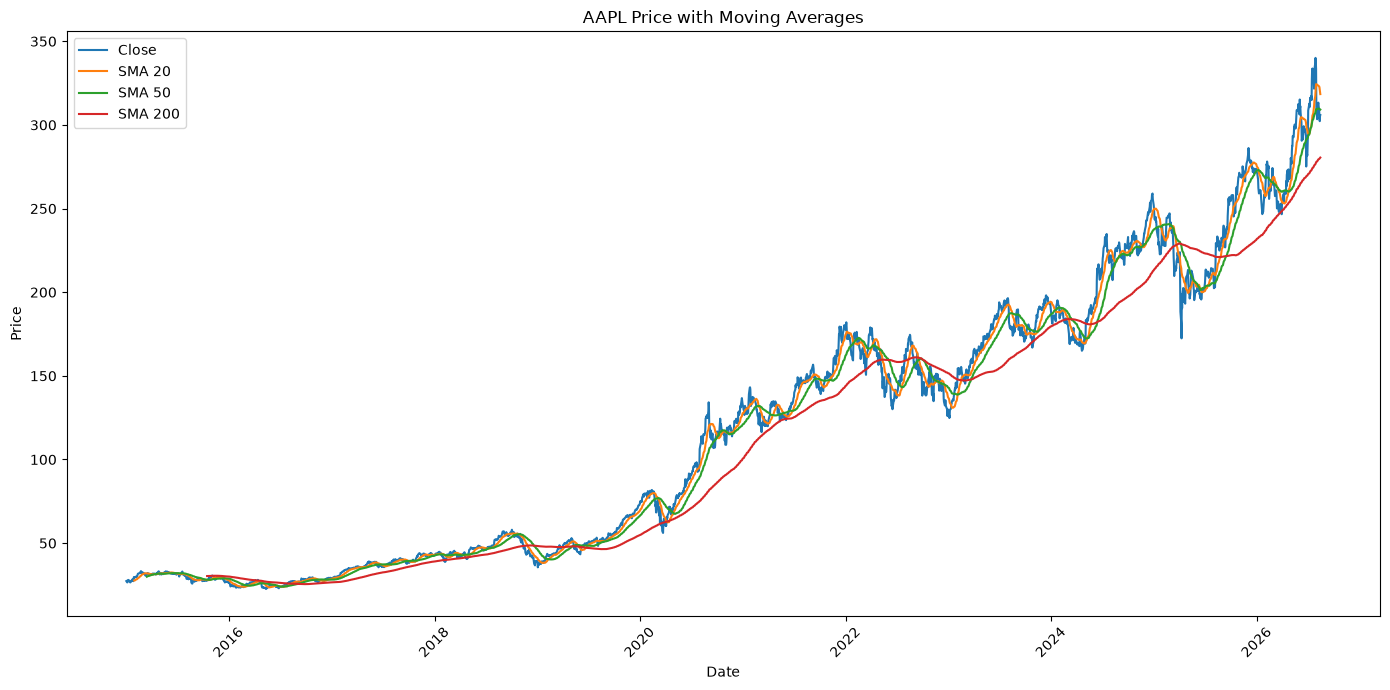

In [27]:
plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Close"],
    label="Close"
)

plt.plot(
    df["Date"],
    df["SMA_20"],
    label="SMA 20"
)

plt.plot(
    df["Date"],
    df["SMA_50"],
    label="SMA 50"
)

plt.plot(
    df["Date"],
    df["SMA_200"],
    label="SMA 200"
)

plt.title(
    "AAPL Price with Moving Averages"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [28]:
df["EMA_20"] = (
    df["Close"]
    .ewm(
        span=20,
        adjust=False
    )
    .mean()
)

df["EMA_50"] = (
    df["Close"]
    .ewm(
        span=50,
        adjust=False
    )
    .mean()
)

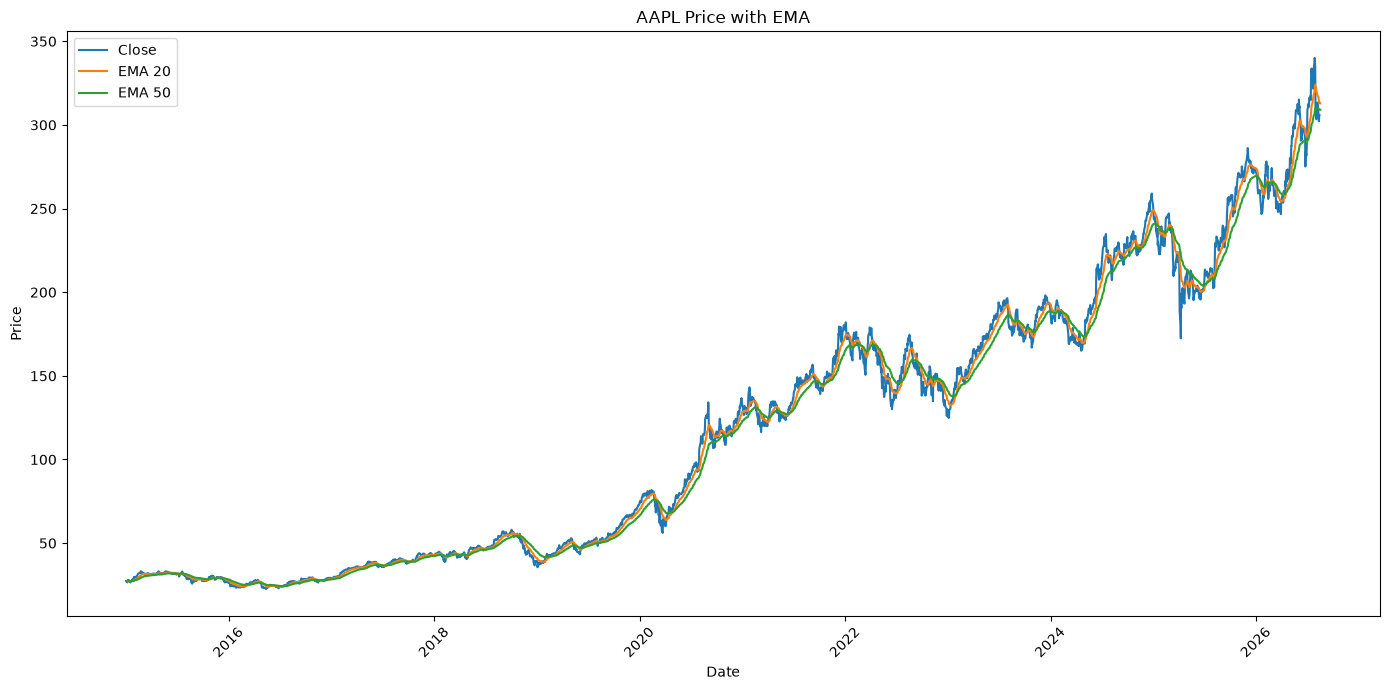

In [29]:
plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Close"],
    label="Close"
)

plt.plot(
    df["Date"],
    df["EMA_20"],
    label="EMA 20"
)

plt.plot(
    df["Date"],
    df["EMA_50"],
    label="EMA 50"
)

plt.title(
    "AAPL Price with EMA"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [30]:
delta = df["Close"].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = (
    100 - (100 / (1 + rs))
)

df[
    ["Date", "Close", "RSI_14"]
].tail()

,Date,Close,RSI_14
2917,2026-08-11,304.910004,36.488903
2918,2026-08-12,302.250000,37.241997
2919,2026-08-13,305.260010,29.503837
2920,2026-08-14,305.929993,25.984454
2921,2026-08-17,NaN,NaN


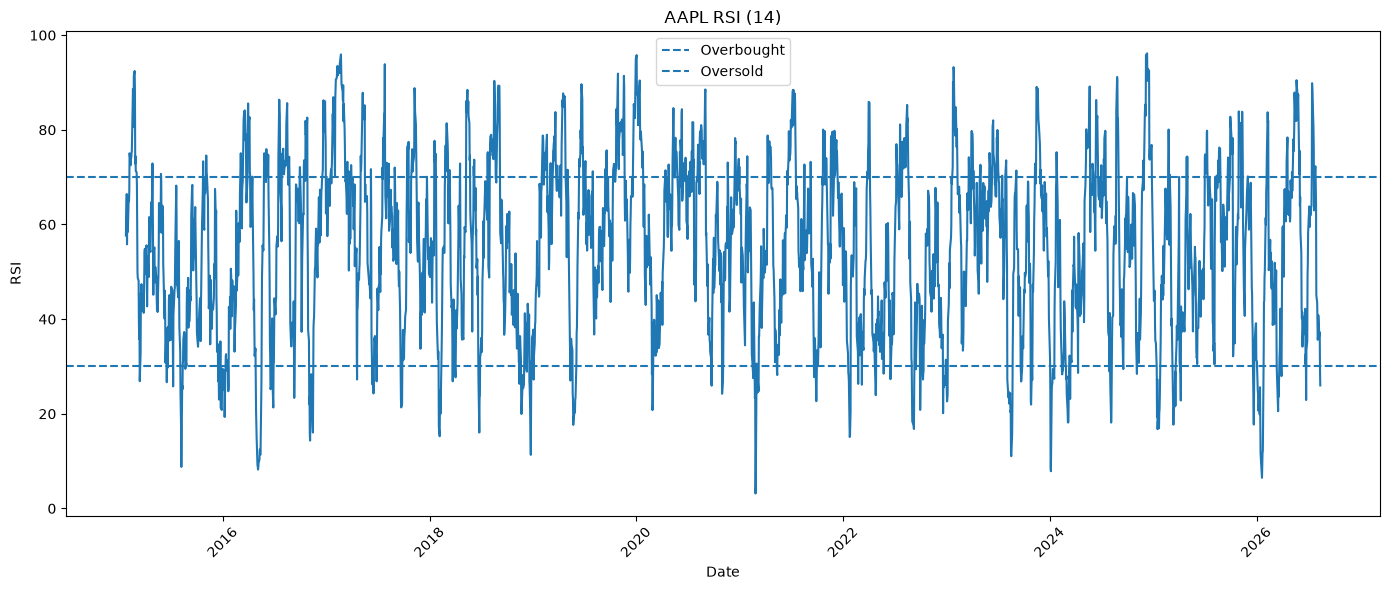

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["RSI_14"]
)

plt.axhline(
    70,
    linestyle="--",
    label="Overbought"
)

plt.axhline(
    30,
    linestyle="--",
    label="Oversold"
)

plt.title(
    "AAPL RSI (14)"
)

plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [32]:
ema_12 = (
    df["Close"]
    .ewm(
        span=12,
        adjust=False
    )
    .mean()
)

ema_26 = (
    df["Close"]
    .ewm(
        span=26,
        adjust=False
    )
    .mean()
)

df["MACD"] = (
    ema_12 - ema_26
)

df["MACD_Signal"] = (
    df["MACD"]
    .ewm(
        span=9,
        adjust=False
    )
    .mean()
)

df["MACD_Histogram"] = (
    df["MACD"]
    - df["MACD_Signal"]
)

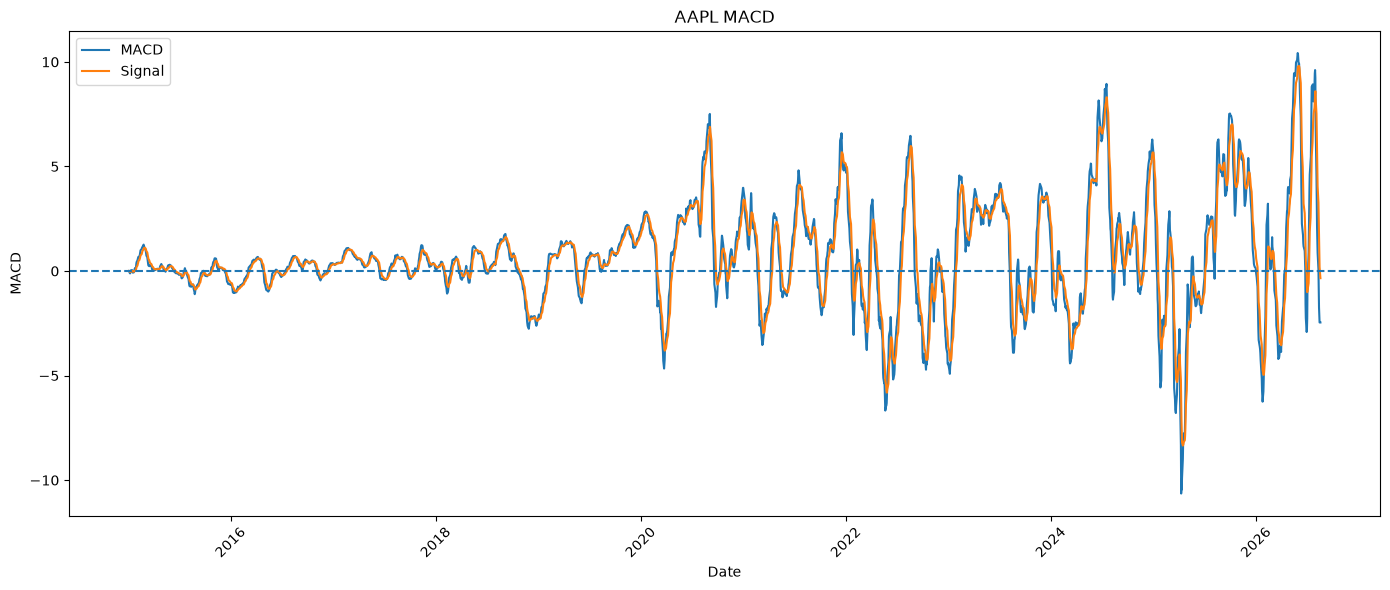

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["MACD"],
    label="MACD"
)

plt.plot(
    df["Date"],
    df["MACD_Signal"],
    label="Signal"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "AAPL MACD"
)

plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [34]:
rolling_mean = (
    df["Close"]
    .rolling(20)
    .mean()
)

rolling_std = (
    df["Close"]
    .rolling(20)
    .std()
)

df["BB_Middle"] = rolling_mean

df["BB_Upper"] = (
    rolling_mean +
    2 * rolling_std
)

df["BB_Lower"] = (
    rolling_mean -
    2 * rolling_std
)

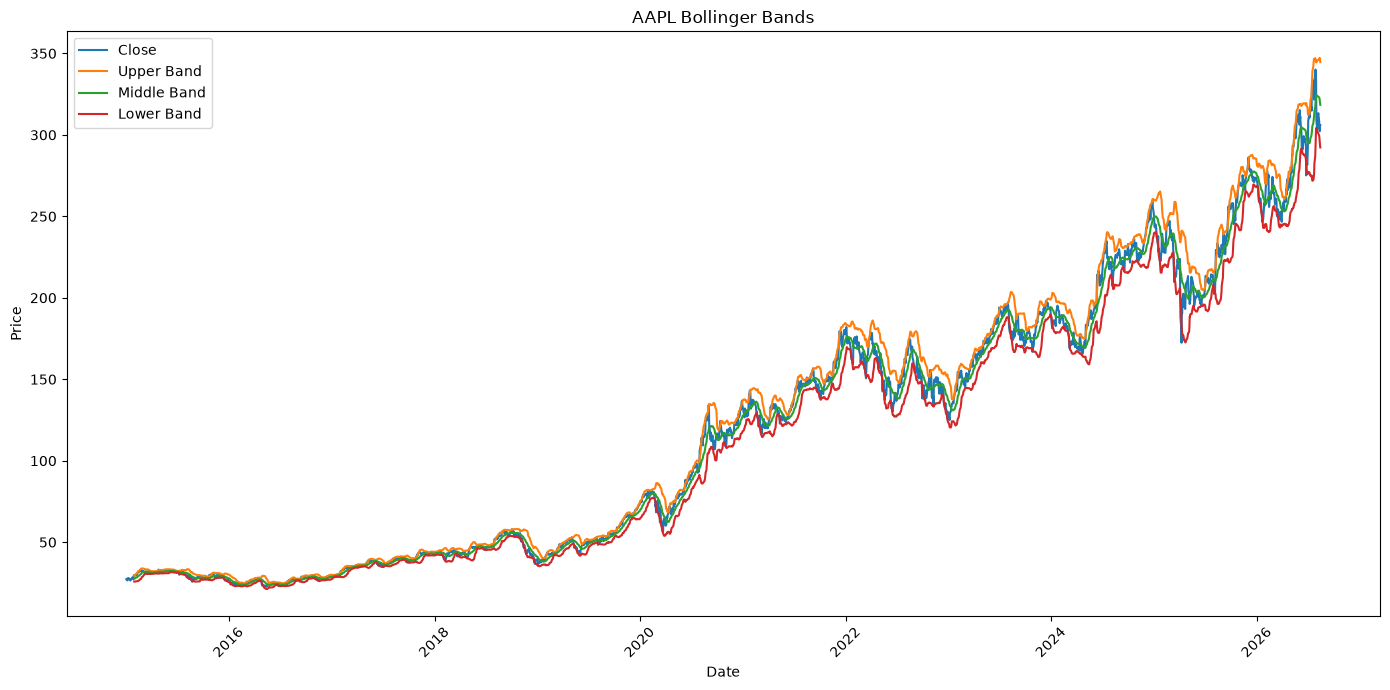

In [35]:
plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Close"],
    label="Close"
)

plt.plot(
    df["Date"],
    df["BB_Upper"],
    label="Upper Band"
)

plt.plot(
    df["Date"],
    df["BB_Middle"],
    label="Middle Band"
)

plt.plot(
    df["Date"],
    df["BB_Lower"],
    label="Lower Band"
)

plt.title(
    "AAPL Bollinger Bands"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [36]:
df["Volatility_20"] = (
    df["Daily_Return"]
    .rolling(20)
    .std()
)

df[
    ["Date", "Volatility_20"]
].tail()

,Date,Volatility_20
2917,2026-08-11,0.023849
2918,2026-08-12,0.021791
2919,2026-08-13,0.021462
2920,2026-08-14,0.021473
2921,2026-08-17,NaN


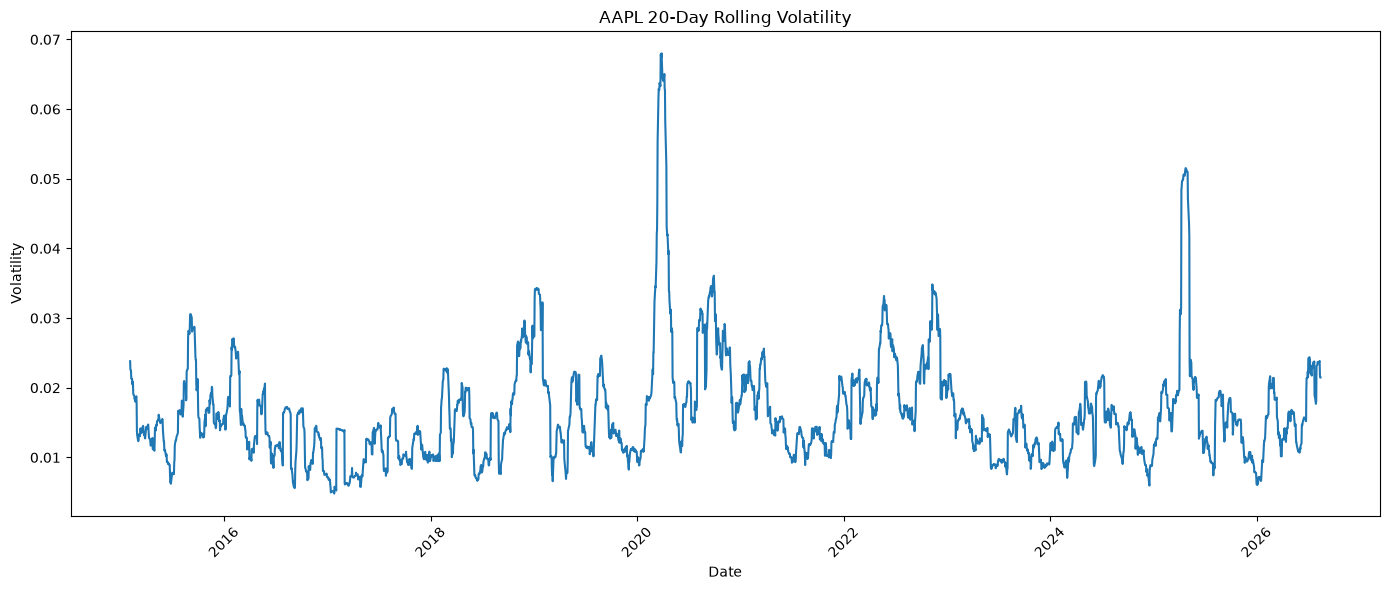

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Volatility_20"]
)

plt.title(
    "AAPL 20-Day Rolling Volatility"
)

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [38]:
df["Close_Lag_1"] = (
    df["Close"].shift(1)
)

df["Close_Lag_2"] = (
    df["Close"].shift(2)
)

df["Close_Lag_3"] = (
    df["Close"].shift(3)
)

df["Close_Lag_5"] = (
    df["Close"].shift(5)
)

df["Close_Lag_10"] = (
    df["Close"].shift(10)
)

df[
    [
        "Date",
        "Close",
        "Close_Lag_1",
        "Close_Lag_2",
        "Close_Lag_5",
        "Close_Lag_10"
    ]
].tail(10)

,Date,Close,Close_Lag_1,Close_Lag_2,Close_Lag_5,Close_Lag_10
2912,2026-08-04,309.380005,303.420013,308.910004,340.079987,327.739990
2913,2026-08-05,311.000000,309.380005,303.420013,338.190002,325.890015
2914,2026-08-06,312.410004,311.000000,309.380005,333.429993,321.660004
2915,2026-08-07,313.329987,312.410004,311.000000,308.910004,333.019989
2916,2026-08-10,308.260010,313.329987,312.410004,303.420013,336.910004
2917,2026-08-11,304.910004,308.260010,313.329987,309.380005,340.079987
2918,2026-08-12,302.250000,304.910004,308.260010,311.000000,338.190002
2919,2026-08-13,305.260010,302.250000,304.910004,312.410004,333.429993
2920,2026-08-14,305.929993,305.260010,302.250000,313.329987,308.910004
2921,2026-08-17,NaN,305.929993,305.260010,308.260010,303.420013


In [39]:
df["Momentum_5"] = (
    df["Close"]
    / df["Close"].shift(5)
    - 1
)

df["Momentum_10"] = (
    df["Close"]
    / df["Close"].shift(10)
    - 1
)

df["Momentum_20"] = (
    df["Close"]
    / df["Close"].shift(20)
    - 1
)

df[
    [
        "Date",
        "Momentum_5",
        "Momentum_10",
        "Momentum_20"
    ]
].tail()

,Date,Momentum_5,Momentum_10,Momentum_20
2917,2026-08-11,-0.014448,-0.103417,-0.031601
2918,2026-08-12,-0.028135,-0.106272,-0.077099
2919,2026-08-13,-0.022887,-0.084485,-0.084018
2920,2026-08-14,-0.023617,-0.009647,-0.083328
2921,2026-08-17,NaN,NaN,NaN


In [40]:
df["Target"] = (
    df["Close"].shift(-1)
)

df[
    [
        "Date",
        "Close",
        "Target"
    ]
].tail(10)

,Date,Close,Target
2912,2026-08-04,309.380005,311.000000
2913,2026-08-05,311.000000,312.410004
2914,2026-08-06,312.410004,313.329987
2915,2026-08-07,313.329987,308.260010
2916,2026-08-10,308.260010,304.910004
2917,2026-08-11,304.910004,302.250000
2918,2026-08-12,302.250000,305.260010
2919,2026-08-13,305.260010,305.929993
2920,2026-08-14,305.929993,NaN
2921,2026-08-17,NaN,NaN


In [41]:
df = (
    df.dropna()
      .reset_index(drop=True)
)

print("Final Shape:", df.shape)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

Final Shape: (2721, 30)
Missing Values: 0


In [42]:
print("Total Features:", len(df.columns))

for i, column in enumerate(
    df.columns,
    start=1
):
    print(
        i,
        column
    )

Total Features: 30
1 Date
2 Adj Close
3 Close
4 High
5 Low
6 Open
7 Volume
8 Daily_Return
9 SMA_20
10 SMA_50
11 SMA_200
12 EMA_20
13 EMA_50
14 RSI_14
15 MACD
16 MACD_Signal
17 MACD_Histogram
18 BB_Middle
19 BB_Upper
20 BB_Lower
21 Volatility_20
22 Close_Lag_1
23 Close_Lag_2
24 Close_Lag_3
25 Close_Lag_5
26 Close_Lag_10
27 Momentum_5
28 Momentum_10
29 Momentum_20
30 Target


In [43]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily_Return,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,RSI_14,MACD,MACD_Signal,MACD_Histogram,BB_Middle,BB_Upper,BB_Lower,Volatility_20,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_10,Momentum_5,Momentum_10,Momentum_20,Target
0,2015-10-16,24.861683,27.760000,28.0000,27.632500,27.945000,156930400,-0.007331,27.942375,28.08690,30.332337,27.906117,28.419614,45.694957,-0.155139,-0.182025,0.026886,27.942375,28.882719,27.002031,0.013303,27.965000,27.552500,27.947500,28.030001,27.594999,-0.009633,0.005979,-0.021243,27.932501
1,2015-10-19,25.016176,27.932501,27.9375,27.527500,27.700001,119036800,0.006214,27.898875,28.06795,30.335337,27.908630,28.400512,59.837888,-0.135251,-0.172670,0.037419,27.898875,28.747727,27.050024,0.012851,27.760000,27.965000,27.552500,27.900000,27.695000,0.001165,0.008576,-0.030206,28.442499
2,2015-10-20,25.472931,28.442499,28.5425,27.705000,27.834999,195871200,0.018258,27.903500,28.03820,30.344737,27.959474,28.402158,62.073740,-0.077445,-0.153625,0.076180,27.903500,28.763634,27.043366,0.013110,27.932501,27.760000,27.965000,27.947500,27.827499,0.017712,0.022100,0.003263,28.440001
3,2015-10-21,25.470699,28.440001,28.8950,28.424999,28.500000,167180800,-0.000088,27.896500,28.03955,30.354112,28.005239,28.403642,65.300152,-0.031472,-0.129195,0.097722,27.896500,28.735471,27.057529,0.012978,28.442499,27.932501,27.760000,27.552500,27.695000,0.032211,0.026900,-0.004899,28.875000
4,2015-10-22,25.860268,28.875000,28.8750,28.525000,28.582500,166616400,0.015295,27.902750,28.04085,30.363800,28.088073,28.422127,67.534258,0.039606,-0.095434,0.135040,27.902750,28.769882,27.035618,0.013372,28.440001,28.442499,27.932501,27.965000,27.375000,0.032541,0.054795,0.004348,29.770000


In [44]:
output_path = (
    "../data/processed/"
    "AAPL_features_notebook.csv"
)

df.to_csv(
    output_path,
    index=False
)

print(
    "Saved successfully:",
    output_path
)

Saved successfully: ../data/processed/AAPL_features_notebook.csv


In [45]:
print("=" * 50)
print("ALPHATRADE PHASE 1 COMPLETE")
print("=" * 50)

print(
    "Dataset Shape:",
    df.shape
)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Start Date:",
    df["Date"].min()
)

print(
    "End Date:",
    df["Date"].max()
)

print(
    "Total Columns:",
    len(df.columns)
)

print("=" * 50)

ALPHATRADE PHASE 1 COMPLETE
Dataset Shape: (2721, 30)
Missing Values: 0
Duplicate Rows: 0
Start Date: 2015-10-16 00:00:00
End Date: 2026-08-13 00:00:00
Total Columns: 30


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

ROOT_DIR = Path.cwd().parent

sys.path.insert(0, str(ROOT_DIR))

RAW_DIR = ROOT_DIR / "data" / "raw"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("ROOT:", ROOT_DIR)
print("RAW:", RAW_DIR)
print("PROCESSED:", PROCESSED_DIR)

ROOT: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade
RAW: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\raw
PROCESSED: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed


In [10]:
def add_lag_features(df):

    df = df.copy()

    for lag in [1, 2, 3, 5, 10]:
        df[f"Return_Lag_{lag}"] = (
            df["Return"].shift(lag)
        )

    return df

In [11]:
def create_target(df):

    df = df.copy()

    # Next day's closing price
    df["Target"] = df["Close"].shift(-1)

    return df

In [12]:
def create_features(ticker):

    input_file = (
        RAW_DIR /
        f"{ticker}_historical.csv"
    )

    output_file = (
        PROCESSED_DIR /
        f"{ticker}_features.csv"
    )

    print(f"\nProcessing {ticker}...")

    if not input_file.exists():

        print(
            f"❌ File not found: {input_file}"
        )

        return None

    df = pd.read_csv(input_file)

    df["Date"] = pd.to_datetime(
        df["Date"]
    )

    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )

    # Technical indicators
    df = add_indicators(df)

    # Lag features
    df = add_lag_features(df)

    # Target
    df = create_target(df)

    # Remove NaN
    df = df.dropna().reset_index(
        drop=True
    )

    # Save
    df.to_csv(
        output_file,
        index=False
    )

    print(
        f"✅ Saved: {output_file}"
    )

    print(
        f"Shape: {df.shape}"
    )

    return df

In [13]:
TICKERS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "TSLA",
    "NVDA"
]

all_data = {}

for ticker in TICKERS:

    result = create_features(ticker)

    if result is not None:
        all_data[ticker] = result


Processing AAPL...
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\AAPL_features.csv
Shape: (2871, 26)

Processing MSFT...
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\MSFT_features.csv
Shape: (2871, 26)

Processing GOOGL...
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\GOOGL_features.csv
Shape: (2871, 26)

Processing AMZN...
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\AMZN_features.csv
Shape: (2871, 26)

Processing TSLA...
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\TSLA_features.csv
Shape: (2871, 26)

Processing NVDA...
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\NVDA_features.csv
Shape: (2871, 26)


In [14]:
for ticker, df in all_data.items():
    print(
        ticker,
        "=>",
        df.shape
    )

AAPL => (2871, 26)
MSFT => (2871, 26)
GOOGL => (2871, 26)
AMZN => (2871, 26)
TSLA => (2871, 26)
NVDA => (2871, 26)


In [15]:
print(
    list(
        PROCESSED_DIR.glob(
            "*_features.csv"
        )
    )
)

[WindowsPath('c:/Users/SHUBHAM/OneDrive/Desktop/AlphaTrade/data/processed/AAPL_features.csv'), WindowsPath('c:/Users/SHUBHAM/OneDrive/Desktop/AlphaTrade/data/processed/AMZN_features.csv'), WindowsPath('c:/Users/SHUBHAM/OneDrive/Desktop/AlphaTrade/data/processed/GOOGL_features.csv'), WindowsPath('c:/Users/SHUBHAM/OneDrive/Desktop/AlphaTrade/data/processed/MSFT_features.csv'), WindowsPath('c:/Users/SHUBHAM/OneDrive/Desktop/AlphaTrade/data/processed/NVDA_features.csv'), WindowsPath('c:/Users/SHUBHAM/OneDrive/Desktop/AlphaTrade/data/processed/TSLA_features.csv')]
